# Day 23 Discriminative Classification

Last time we looked at generative classification where we mapped the full pdf of the data's feature space and probabilistically ranked the population that a new sample would belong to.

So this time we shall look at discriminative classification, where to try to determine the decision boundary as shown below:

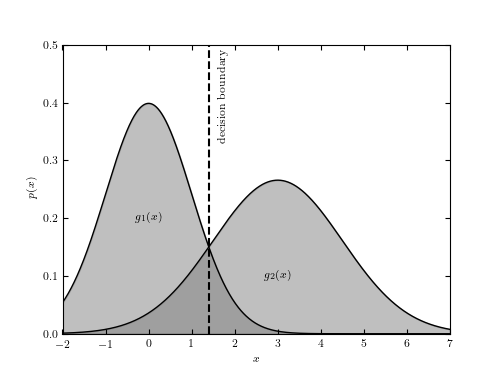

If we have 2 random sets of data points, this may be done by drawing a line where we think the blobs are well separated, but that leads us to questions of how can we do this optimally. And what if they're kind of overlapping?



In [207]:
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

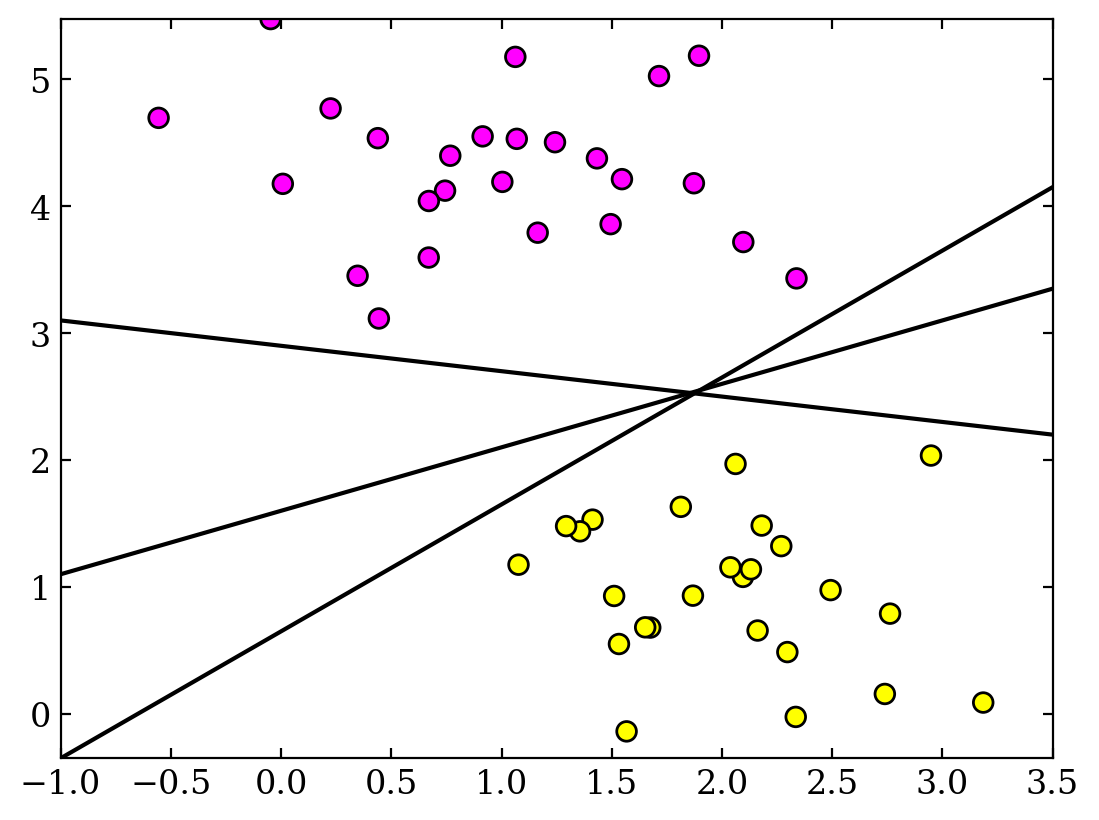

In [208]:
# Source: https://github.com/jakevdp/ESAC-stats-2014/blob/master/notebooks/04.1-Classification-SVMs.ipynb
import numpy as np
from scipy import stats
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='spring' ,edgecolor='k');

Xgrid = np.linspace(-1, 3.5)
for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]: # first number is the gradient and 2nd is the intercept
    plt.plot(Xgrid, m * Xgrid + b, '-k')
    
plt.xlim(-1, 3.5);

We can see there are many different straight lines that can perfectly separate the two classes, which one should we chosoe (This motivates SVMs)

### Logistic Regression

Confusingly called regression but its a classification method


Remember from yesterday, within LDA we assumed two classes are multivariate Gaussians and that they share the same covariance matrix.

The Bayes' theorem gave us the comparison of the posterior probabilities

$$ \frac{p(y=1|x)}{p(y=0|x)} $$



This shows that after seeing the data, how much more likely is class 1 than class 0.

If we take the logarithm, we recover:

$$\begin{align}
      \ln\left( \frac{p(y=1|x)}{p(y=0|x)} \right) &= -\frac{1}{2}(\mu_0+\mu_1)^T\Sigma^{-1}(\mu_0-\mu_1) + \ln\frac{p(y=0)}{p(y=1)} + x^T\Sigma^{-1}(\mu_1-\mu_0) = \alpha_0 + \alpha^T x,
\end{align}$$


The parts that didn't depend on $x$ were just transformed into a constant. And this is linear in the features.

**ANYWAYS if we go back to Logistic Regression** we can model the class probability directly in the form:

$$\ln\left( \frac{p(y=1|x)}{p(y=0|x)} \right) = \beta_0 + \beta^T x$$

Where we see that the only difference between the two is how the regression coefficients are estimated. In LDA they were chosen to minimise the density estimation error, whereas in Logistic Regression they are chosen to minimise the classification error.

Let's try this on the RR Lyrae stars as we have done before:

completeness [0.98540146 1.         1.         1.        ]
contamination [0.88588335 0.84180139 0.84088269 0.84088269]


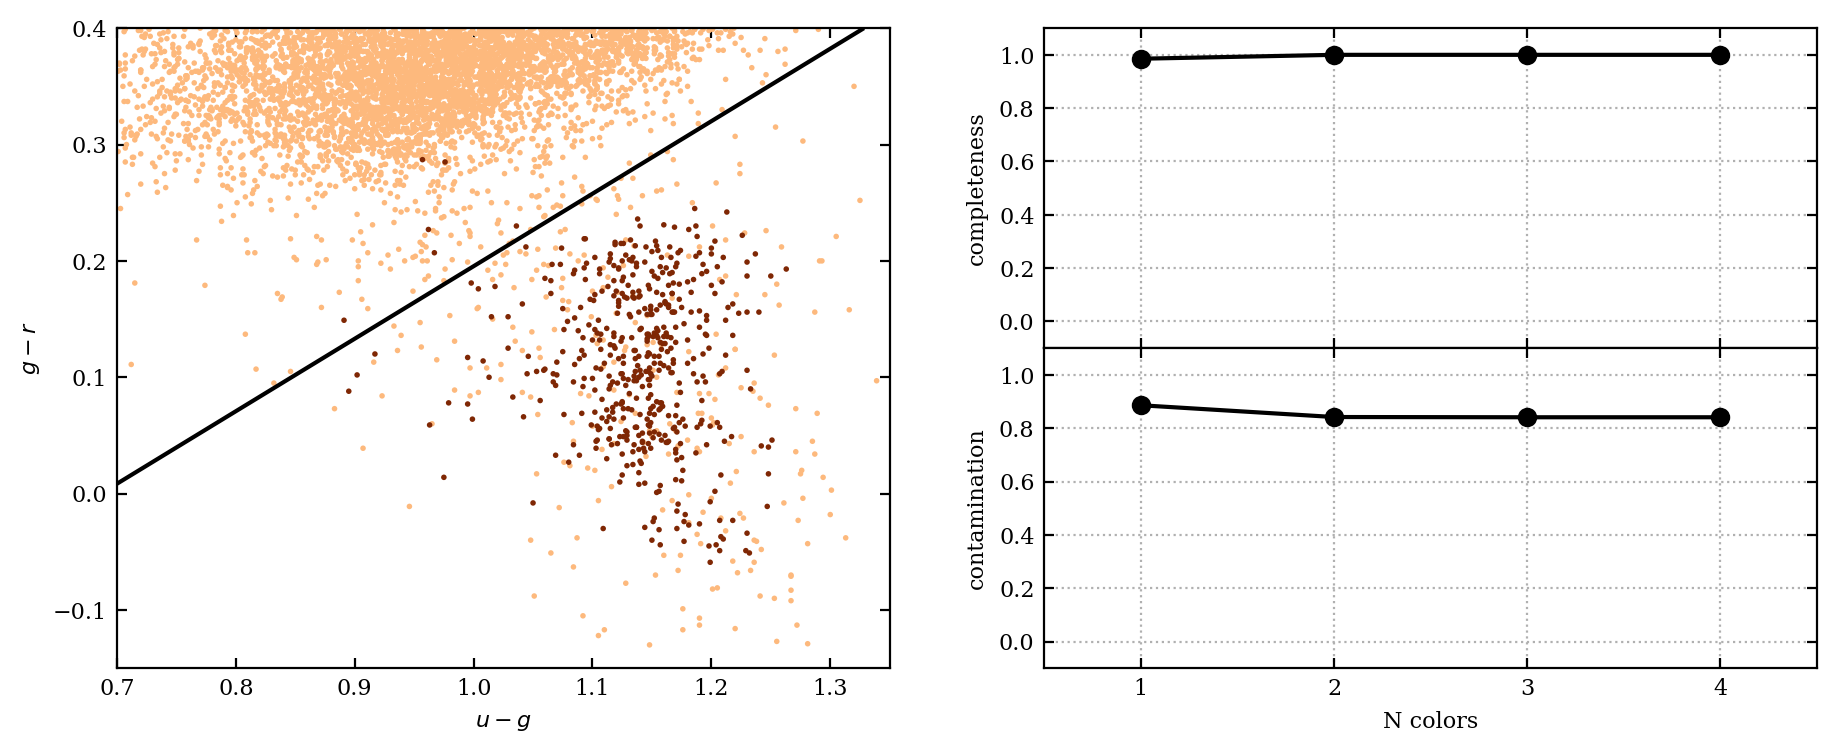

In [209]:
# # Ivezic v2, Figure 9.8, edits by SRT
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from matplotlib import colors

from sklearn.linear_model import LogisticRegression
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples
from astroML.utils import completeness_contamination

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#----------------------------------------------------------------------
# get data and split into training & testing sets
Xnew, ynew = fetch_rrlyrae_combined()
Xnew = Xnew[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results
(X_train, X_test), (y_train, y_test) = split_samples(Xnew, ynew, [0.75, 0.25],
                                                     random_state=0)

N_tot = len(ynew)
N_st = np.sum(ynew == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr

#----------------------------------------------------------------------
# perform Classification
classifiers = []
predictions = []
Ncolors = np.arange(1, Xnew.shape[1] + 1)

for nc in Ncolors:
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(X_train[:, :nc], y_train)
    y_pred = clf.predict(X_test[:, :nc])

    classifiers.append(clf)
    predictions.append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

#------------------------------------------------------------
# Compute the decision boundary
clf = classifiers[1]
xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71),
                     np.linspace(ylim[0], ylim[1], 81))

Z = clf.predict_proba(np.c_[yy.ravel(), xx.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(Xnew[-N_plot:, 1], Xnew[-N_plot:, 0], c=ynew[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

# plot completeness vs Ncolors
ax = fig.add_subplot(222)

ax.plot(Ncolors, completeness, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))
ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

### Support Vector Machines

SVMs define a hyperplane (a plane in N-1 dimensions) that maximised the distance of the closest points from each class. This distance is called the margin. It is the width of the "street" that you put between the closest points that just barely touch the points in the class. The points that touch the margin are called support vectors.

This image helps the explanation quite a lot.

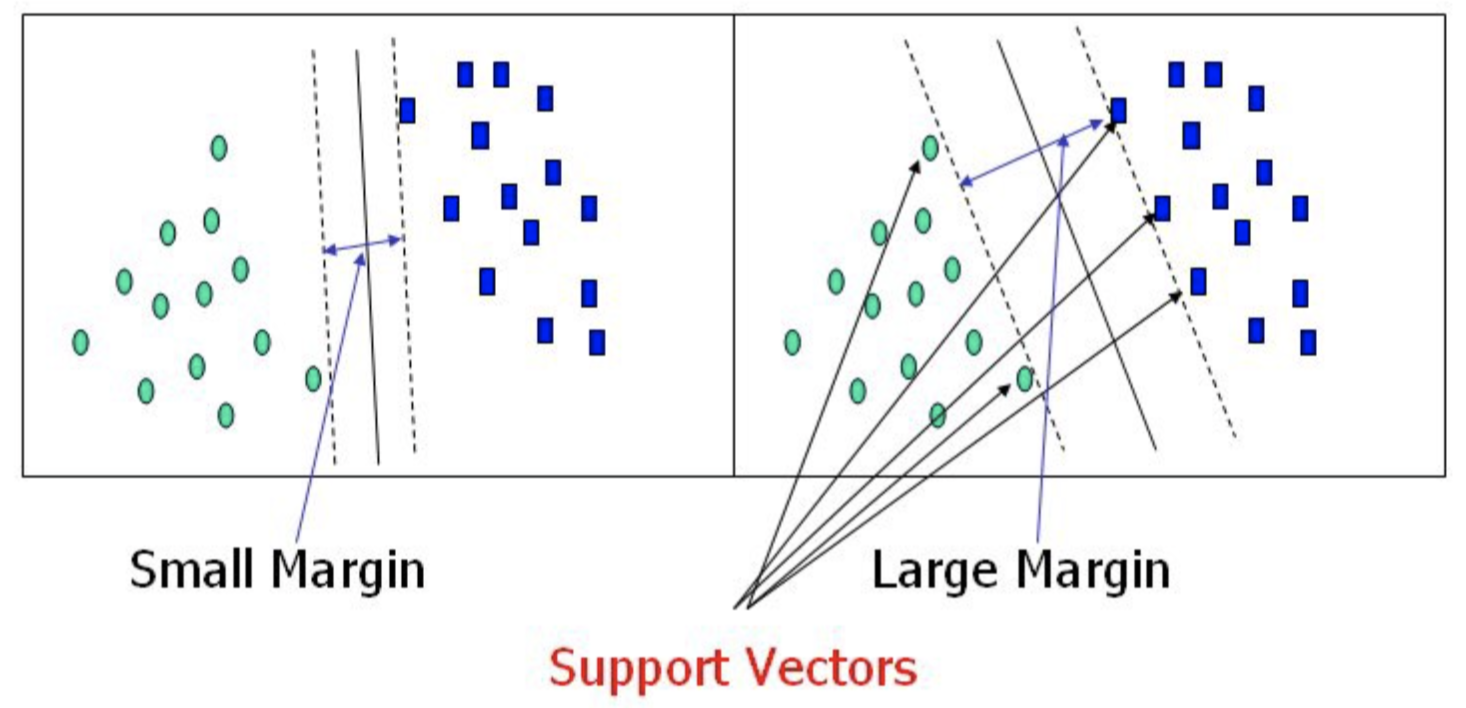


If we look at the example that we had motivating SVMs, we can go back to it and maximise the distance of the support vectors from the decision hyperplane.



(-1.0, 3.5)

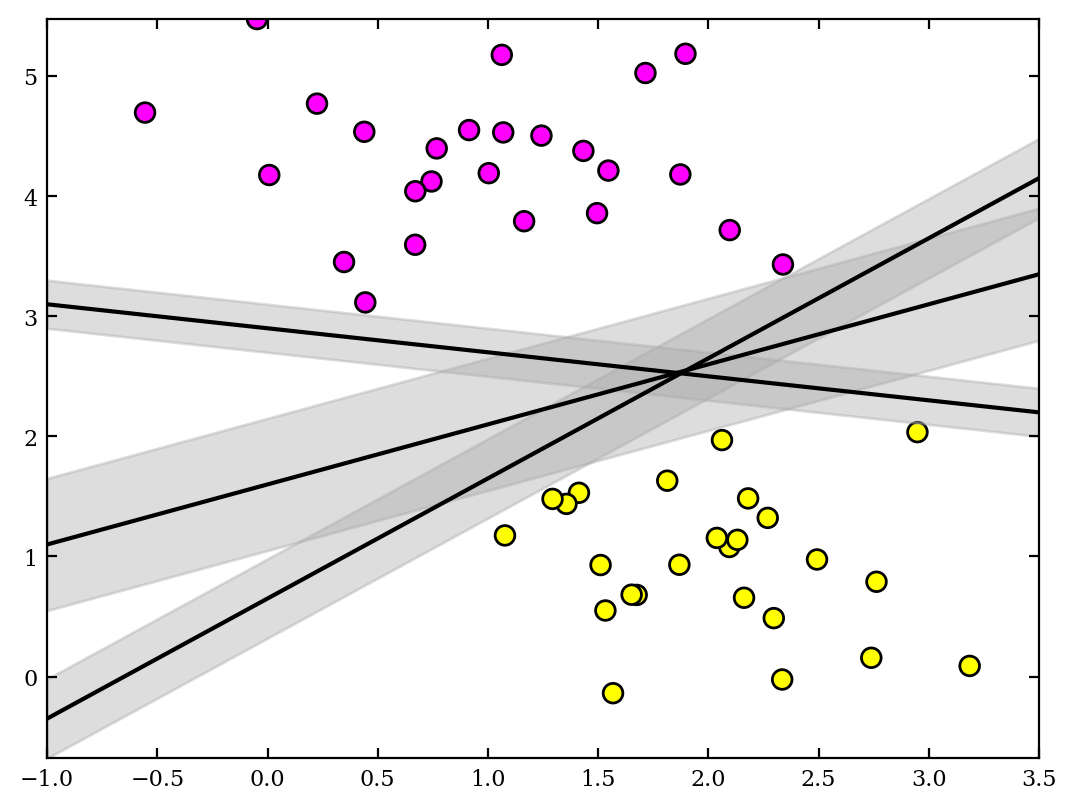

In [210]:
Xgrid = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], 
            c=y, s=50, cmap='spring', 
            edgecolor='k')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * Xgrid+ b
    plt.plot(Xgrid, yfit, '-k')
    plt.fill_between(Xgrid, yfit - d, yfit + d, 
                     edgecolor='None', 
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5)

We first assume the classes are linearly separable, and say $y \in {-1,1}$

So we start with a normal linear boundary $ \beta_0 + \beta^T x = 0$, and applying the constraint means correct side: $ y_i(\beta_0 + \beta^T x)  > 0$. We divide by $||\beta||$ to get a distance and ensure that every distance is at least $m$.



The hyperplane that maximises the margin is given by finding:


\begin{equation}
\max_{\beta_0,\beta} (m) \quad \text{subject to} \quad \frac{1}{\|\beta\|} y_i ( \beta_0 + \beta^T x_i ) \geq m \quad \forall \, i
\end{equation}

So we are trying to make m as large as possible while trying to keep every point atleast an m distance from the boundary.

$$\quad y_i ( \beta_0 + \beta^T x_i ) \geq 1 \quad \forall \, i$$

We choose a convenient scale such that $||\beta || = \frac{1}{m}$, we can do this because scaling it creates the exact same geometric line. And doesn't change the boundary.

\begin{equation}
\min_{\beta_0,\beta} \frac{1}{2} \|\beta\| \quad \text{subject to} \quad y_i ( \beta_0 + \beta^T x_i ) \geq 1 \quad \forall \, i
\end{equation}

So to maximise the margin, we minimise the value of $\beta$

For real data we can relax the assumption that the classes are linearly separable, this changes the minimisation condition and puts bounds on the number of misclassifications which we want to minimise.

> If the classes clearly overlap, then we can not make the demand that it must be greater than 1 for every point so we use soft margin SVM where some of the points are allowed to be misclassified or sit inside the margin. We can include a $C$ parameter that punishes the SVM for mistakes, causing a narrower margin if $C$ is larger.

Implementation of SVM using scikit learn as follows:

In [211]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1.0) # will explain 'C' below
svm.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [212]:
def plot_svc_decision_function(clf, ax=None):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    u = np.linspace(plt.xlim()[0], plt.xlim()[1], 30)
    v = np.linspace(plt.ylim()[0], plt.ylim()[1], 30)
    yy, xx = np.meshgrid(v, u)

    P = np.zeros_like(xx)
    for i, ui in enumerate(u):
        for j, vj in enumerate(v):
            Xgrid = np.array([ui, vj])
            P[i, j] = clf.decision_function(Xgrid.reshape(1,-1))[0]
    return ax.contour(xx, yy, P, colors='k',
                      levels=[-1, 0, 1], alpha=0.5,
                      linestyles=['--', '-', '--'])

This code is a convenience function that will plot the decision boundaries for us.

### We will look at the case when data overlap later as a coding exercise

@pickle_results: using precomputed results from 'SVM_rrlyrae.pkl'
completeness [0.99270073 1.         1.         1.        ]
contamination [0.90014684 0.85347594 0.85347594 0.85471898]


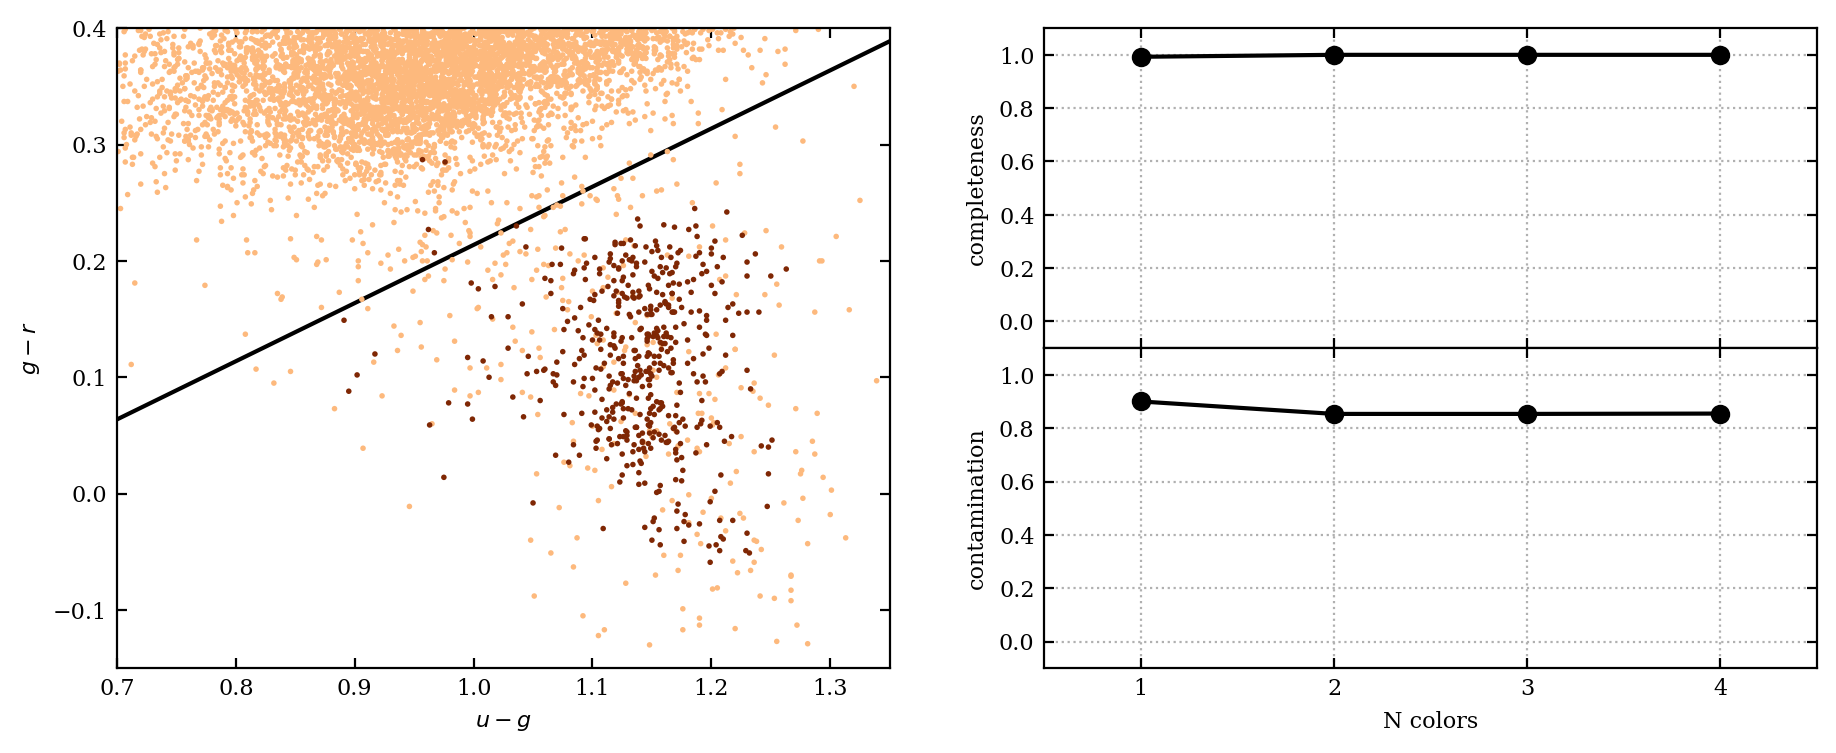

In [213]:
# Ivezic v2, Figure 9.10, edits by GTR and SRT
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from sklearn.svm import SVC
from astroML.utils.decorators import pickle_results
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples
from astroML.utils import completeness_contamination
from matplotlib import colors

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results

# SVM takes several minutes to run, and is order[N^2]
#  truncating the dataset can be useful for experimentation.
#X = X[::5]
#y = y[::5]

(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

N_tot = len(y)
N_st = np.sum(y == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr

#----------------------------------------------------------------------
# Fit SVM
Ncolors = np.arange(1, X.shape[1] + 1)


@pickle_results('SVM_rrlyrae.pkl')
def compute_SVM(Ncolors):
    classifiers = []
    predictions = []

    for nc in Ncolors:
        # perform support vector classification
        clf = SVC(kernel='linear', class_weight='balanced')
        clf.fit(X_train[:, :nc], y_train)
        y_pred = clf.predict(X_test[:, :nc])

        classifiers.append(clf)
        predictions.append(y_pred)

    return classifiers, predictions

classifiers, predictions = compute_SVM(Ncolors)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

#------------------------------------------------------------
# compute the decision boundary
clf = classifiers[1]
w = clf.coef_[0]
a = -w[0] / w[1]
yy = np.linspace(-0.1, 0.4)
xx = a * yy - clf.intercept_[0] / w[1]

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
ax.plot(xx, yy, '-k')
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

ax.set_xlim(0.7, 1.35)
ax.set_ylim(-0.15, 0.4)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

# plot completeness vs Ncolors
ax = fig.add_subplot(222)
ax.plot(Ncolors, completeness, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

#### A couple of notes on this:

- The median of the distribution is unaffected by large perturbations of outlying points as long as they don't cross the boundary
- Once the support vectors are determined, changes to the position or number of points beyond hte margin will not change the decision boundary, hence quite powerful.
- As SVM is not scale invariant, make sure to rescale the data down to [0,1] or to whiten it to have mean 0 and variance 1.
- The data doesn't need to be separable, we can put a constraint in minimising the number of failures.

### Kernel Methods

What if we want a non linear decision boundary? 

This would be usually done when our contamination is driven by non linear effects. This can be done through kernalisation

Let's have a look:

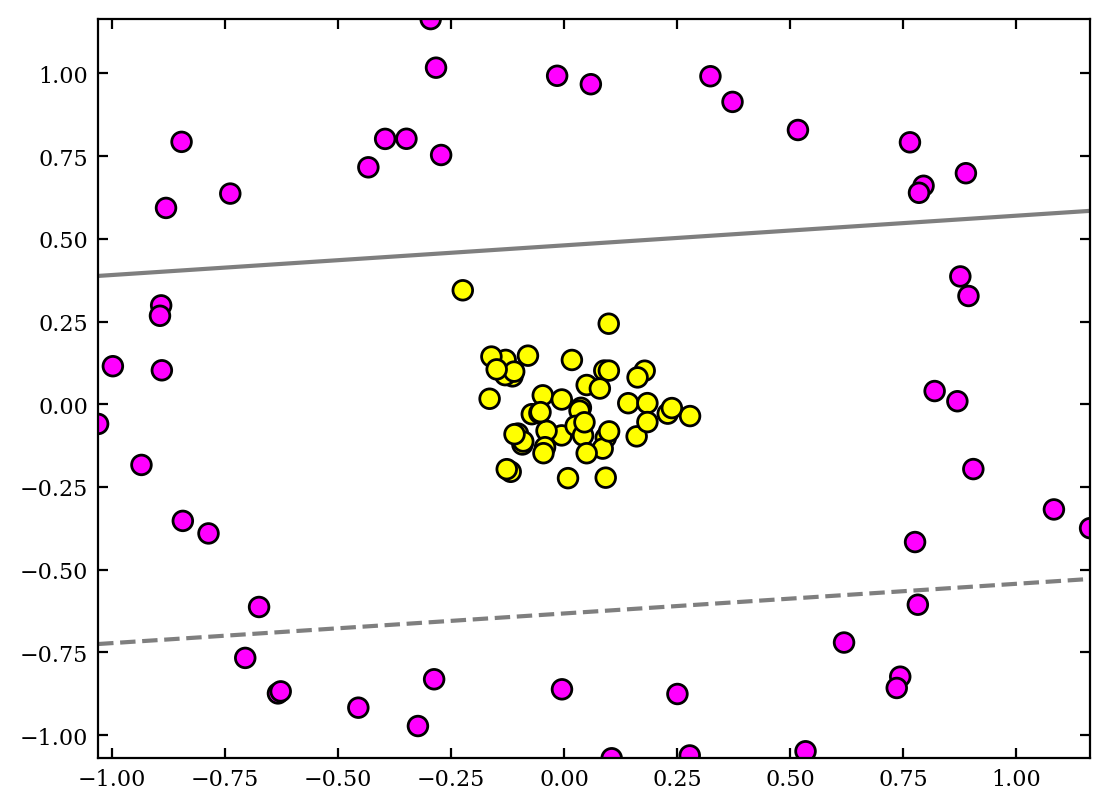

In [214]:
from sklearn.datasets import make_circles

X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y) # I messed around with the kernel and continuously ran it

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, 
            cmap='spring', edgecolor='k')
plot_svc_decision_function(clf);

We can transform the data to make it linearly separable. Like using a radial basis function as shown below:

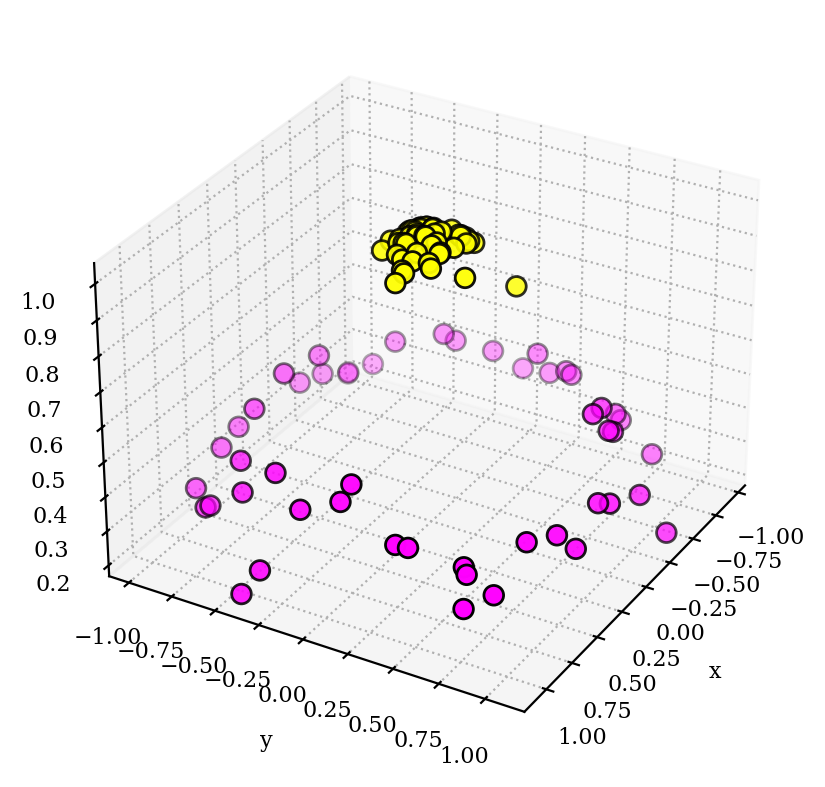

In [215]:
# Define a new feature that is related to the square of the input features.
# Points near and far from the origin will end up far away from each other.
z = np.exp(-(X[:, 0] ** 2 + X[:, 1] ** 2))

from ipywidgets import interact
#from mpl_toolkits import mplot3d

def plot_3D(elev=30, azim=30):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], z, c=y, 
                 s=50, cmap='spring', edgecolor='k')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

plot_3D()

So we should choose a decision boundary that is radial, emanating from the origin so we can trivially separate them.


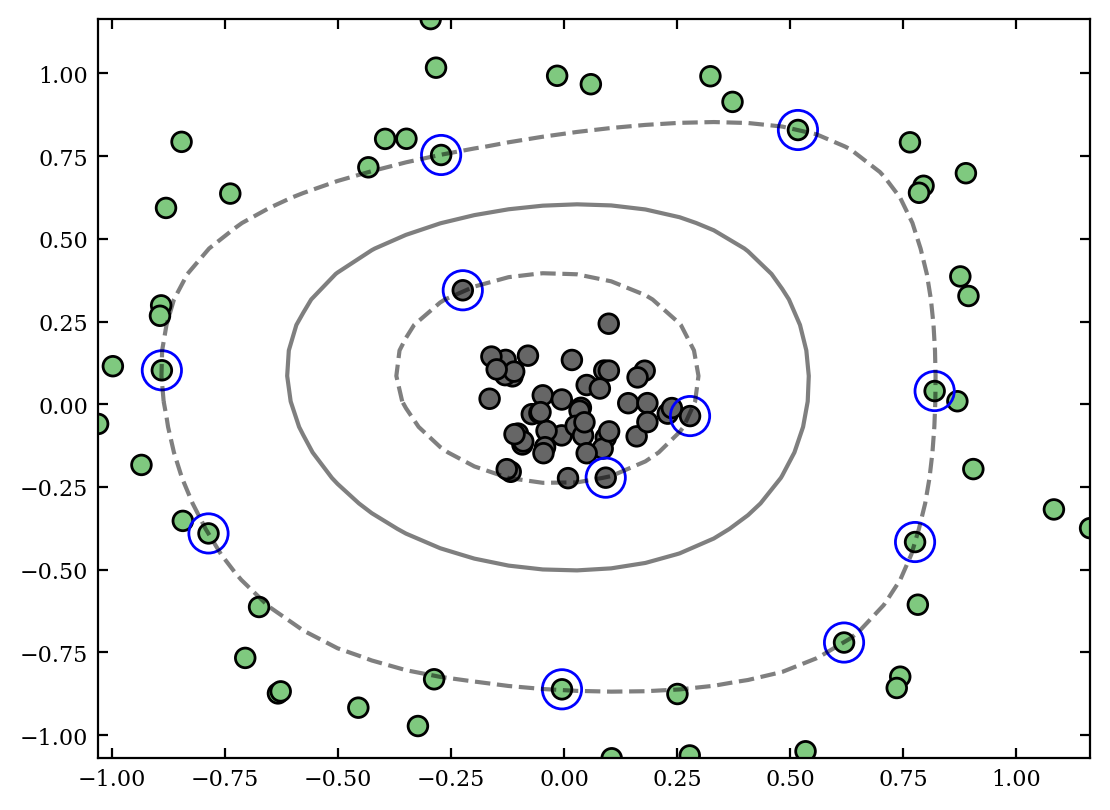

In [216]:
clf = SVC(kernel='rbf',C=10)
clf.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, 
            cmap='Accent', edgecolor='k')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], 
            clf.support_vectors_[:, 1],
            s=200, facecolors='none');

### Decision Trees

The decision boundaries discussed can be applied hierarchically to a data set, and this creates a decision tree. 

So what we do is 
- define some criteria to separate a sample into two groups
- Take those subsamples and do it again
- Keep going until you reach a stopping point, this can be things like not having a minimum number of objects to split again.

The structure of the tree is as follows:
- The top node contains the entire data set
- At each branch the data are subdivided into two child nodes
- The split is based on a predefined (usually axis aligned) decision boundary
- Splitting repeats until we reach a predfined stopping criteria.

This can look as follows:

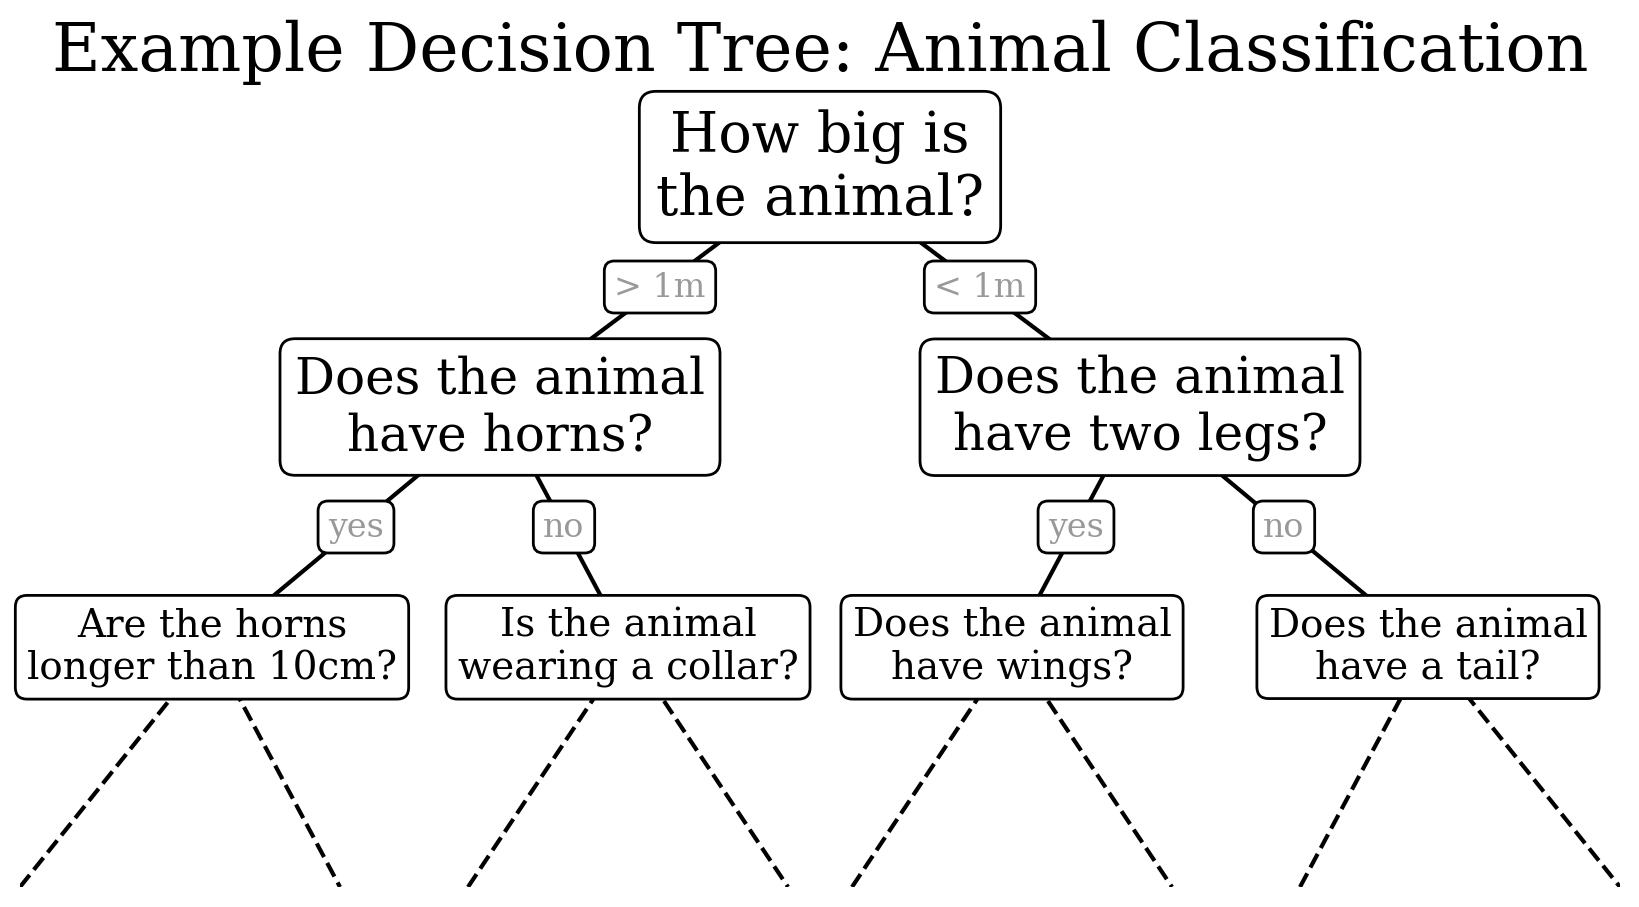

In [217]:
# Source: Jake VanderPlas, https://github.com/LocalGroupAstrostatistics2015/MachineLearning/blob/master/fig_code/figures.py
def plot_example_decision_tree():
    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_axes([0, 0, 0.8, 1], frameon=False, xticks=[], yticks=[])
    ax.set_title('Example Decision Tree: Animal Classification', size=24)

    def text(ax, x, y, t, size=20, **kwargs):
        ax.text(x, y, t,
                ha='center', va='center', size=size,
                bbox=dict(boxstyle='round', ec='k', fc='w'), **kwargs)

    text(ax, 0.5, 0.9, "How big is\nthe animal?", 20)
    text(ax, 0.3, 0.6, "Does the animal\nhave horns?", 18)
    text(ax, 0.7, 0.6, "Does the animal\nhave two legs?", 18)
    text(ax, 0.12, 0.3, "Are the horns\nlonger than 10cm?", 14)
    text(ax, 0.38, 0.3, "Is the animal\nwearing a collar?", 14)
    text(ax, 0.62, 0.3, "Does the animal\nhave wings?", 14)
    text(ax, 0.88, 0.3, "Does the animal\nhave a tail?", 14)

    text(ax, 0.4, 0.75, "> 1m", 12, alpha=0.4)
    text(ax, 0.6, 0.75, "< 1m", 12, alpha=0.4)

    text(ax, 0.21, 0.45, "yes", 12, alpha=0.4)
    text(ax, 0.34, 0.45, "no", 12, alpha=0.4)

    text(ax, 0.66, 0.45, "yes", 12, alpha=0.4)
    text(ax, 0.79, 0.45, "no", 12, alpha=0.4)

    ax.plot([0.3, 0.5, 0.7], [0.6, 0.9, 0.6], '-k')
    ax.plot([0.12, 0.3, 0.38], [0.3, 0.6, 0.3], '-k')
    ax.plot([0.62, 0.7, 0.88], [0.3, 0.6, 0.3], '-k')
    ax.plot([0.0, 0.12, 0.20], [0.0, 0.3, 0.0], '--k')
    ax.plot([0.28, 0.38, 0.48], [0.0, 0.3, 0.0], '--k')
    ax.plot([0.52, 0.62, 0.72], [0.0, 0.3, 0.0], '--k')
    ax.plot([0.8, 0.88, 1.0], [0.0, 0.3, 0.0], '--k')
    ax.axis([0, 1, 0, 1])

plot_example_decision_tree()

There are terminal nodes, noted as the leaf nodes that record the fraction of points that have one classification or the other in a training set.

The fraction of points from the training set classified as belonging to one class or the other in the leaf node defines the class associated with that leaf node.

These are split in a binary fashion which makes it very efficient. But we have to make sure we are asking the right questions.

This can be implemented as follows:

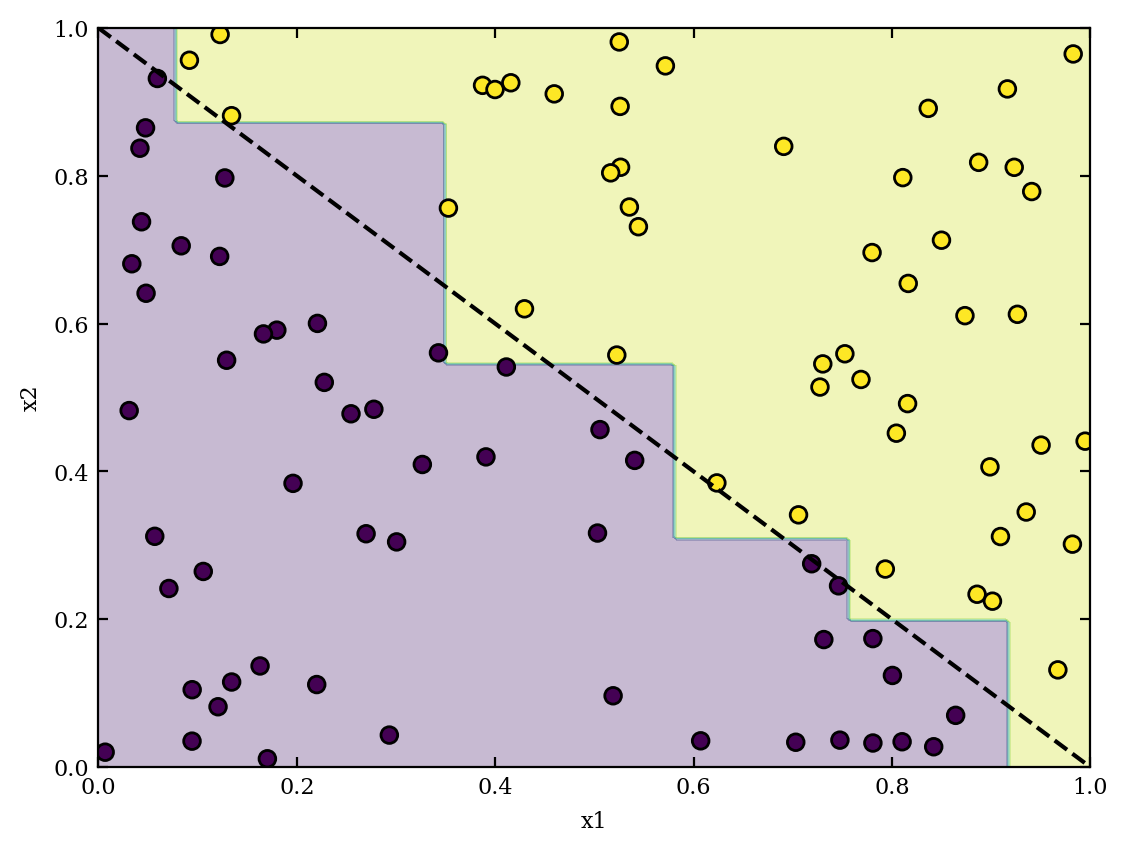

In [218]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier


# Make data
X = np.random.random((100, 2))
y = (X[:, 0] + X[:, 1] > 1).astype(int) # defines the true classes


# Train tree
tree = DecisionTreeClassifier(max_depth=1000)
tree.fit(X, y)


# Make grid
x1 = np.linspace(0, 1, 200)
x2 = np.linspace(0, 1, 200)
xx, yy = np.meshgrid(x1, x2)


grid = np.c_[xx.ravel(), yy.ravel()]
Z = tree.predict(grid).reshape(xx.shape)


# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)


# Plot data
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')


# True boundary
plt.plot(x1, 1 - x1, 'k--')


plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

The black dashed line is rule we used to create the labels. The shading is what the decision tree has learned. Increasing the max depth reduces bias but clearly increases variance.

Let's look at the RR Lyrae example:

completeness [[0.         0.         0.         0.        ]
 [0.01459854 0.31386861 0.46715328 0.56934307]]
contamination [[0.         0.         0.         0.        ]
 [0.81818182 0.5326087  0.43859649 0.39534884]]


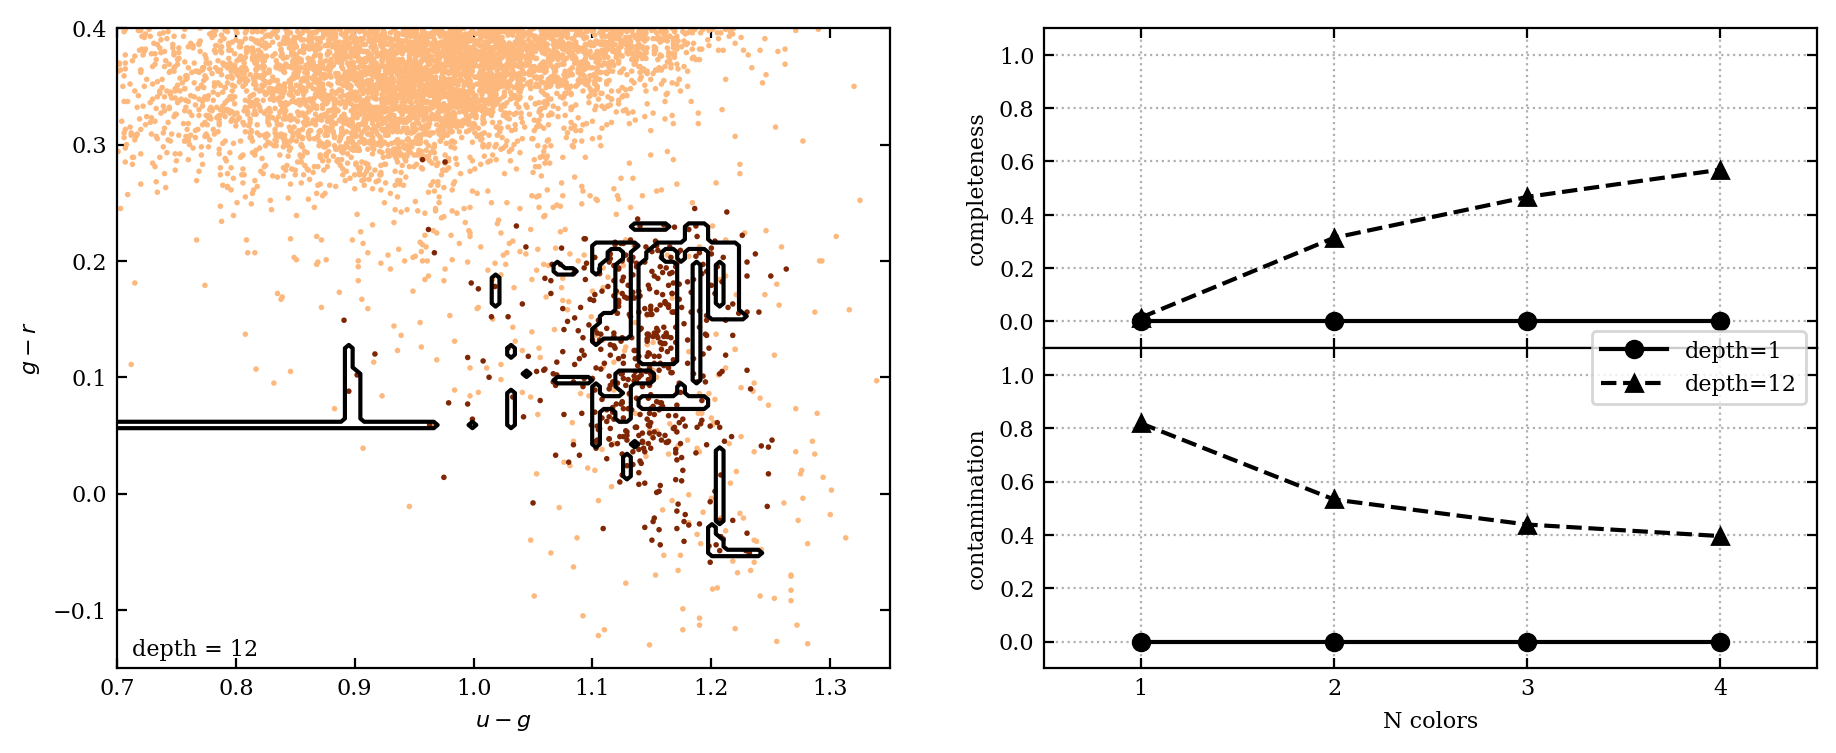

In [219]:
# Ivezic v2, Figure 9.13, edits by GTR and SRT
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from sklearn.tree import DecisionTreeClassifier
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples
from astroML.utils import completeness_contamination

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results
(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)
N_tot = len(y)
N_st = np.sum(y == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr

#----------------------------------------------------------------------
# Fit Decision tree
Ncolors = np.arange(1, X.shape[1] + 1)

classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)
depths = [1, 12]

for depth in depths:
    classifiers.append([])
    predictions.append([])
    for nc in Ncolors:
        clf = DecisionTreeClassifier(random_state=0, max_depth=depth,
                                     criterion='gini')
        clf.fit(X_train[:, :nc], y_train)
        y_pred = clf.predict(X_test[:, :nc])

        classifiers[-1].append(clf)
        predictions[-1].append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

#------------------------------------------------------------
# compute the decision boundary

clf = classifiers[1][1]
xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 101),
                     np.linspace(ylim[0], ylim[1], 101))

Z = clf.predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

ax.text(0.02, 0.02, "depth = %i" % depths[1],
        transform=ax.transAxes)

# plot completeness vs Ncolors
ax = fig.add_subplot(222)
ax.plot(Ncolors, completeness[0], 'o-k', ms=6, label="depth=%i" % depths[0])
ax.plot(Ncolors, completeness[1], '^--k', ms=6, label="depth=%i" % depths[1])

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination[0], 'o-k', ms=6, label="depth=%i" % depths[0])
ax.plot(Ncolors, contamination[1], '^--k', ms=6, label="depth=%i" % depths[1])
ax.legend(loc='lower right',
          bbox_to_anchor=(1.0, 0.79))

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

We can see that at a depth of 12, there is higher variance and we have probably overfit. Also from the later parts, I used the Gini criterion

### Splitting Criteria

A way of doing this is by using the Entropy (information content) of the data:

$$E(x) = -\sum_i p_i(x) \ln (p_i(x)),$$

where $i$ is the class and $p_i(x)$ is the probably of that class given the training data. 

> If there is high entropy, the classes are strongly mixed

We can define the **information gain** as the reduction in entropy due to partioning of the data as we would have reduced the disorder.

For a binary split with $i = 0 representing the points below the split threshold and $i=1$ as the points above the split threshold. The information gain $IG(x)$ is:

$$IG(x|x_i) = E(\text{Parent}) - \sum_{i=0}^1 \frac{N_i}{N}E(x_i),$$

Where $N_i$ is the number of points, $x_i$ is the child subset. We are assessing the information gain as the difference between the entropy of the parent node and the sumof the entropies of the child nodes. The informaation gain is also referred to as the KL divergence

Finding the optimal decision boundary is extremely hard so we consider each feature one at a time, and the feature that provided the largest information gain is split.

For a particular feature, $x$, we then need to decide where along the feature to split the data and we introduce a split value $x < s$ and $x \ge s$

For each possible value of $s$, we calculate the weighted entropy of the two resulting child nodes and choose the value of $s$ which gives the greatest reduction in entropy.

Hence the splitting criteria is:

\begin{equation}
IG(x|s) = E(x) - \operatorname{arg\,max}_s \left( \frac{N(x|x < s)}{N} E(x|x < s) - \frac{N(x|x \geq s)}{N} E(x|x \geq s) \right) \tag{9.47}
\end{equation}

### Another common loss function is the Gini coefficient

$$G = \sum_i^k p_i(1-p_i).$$

This estimates the probability of incorrect classification by choosing both a point and a class randomly from the data.

---

If the choice of stopping criteria is too loose, then you add noise through further splitting. Our best friend cross validation can help to optimise the depth of the tree and help avoid overfitting. This is regularisation.

In the following example we see this in use, and we use regression which is basically a continuous classifier rather than the discrete classifier we have been using. We are using the colours of the galaxies to predict their redshift.

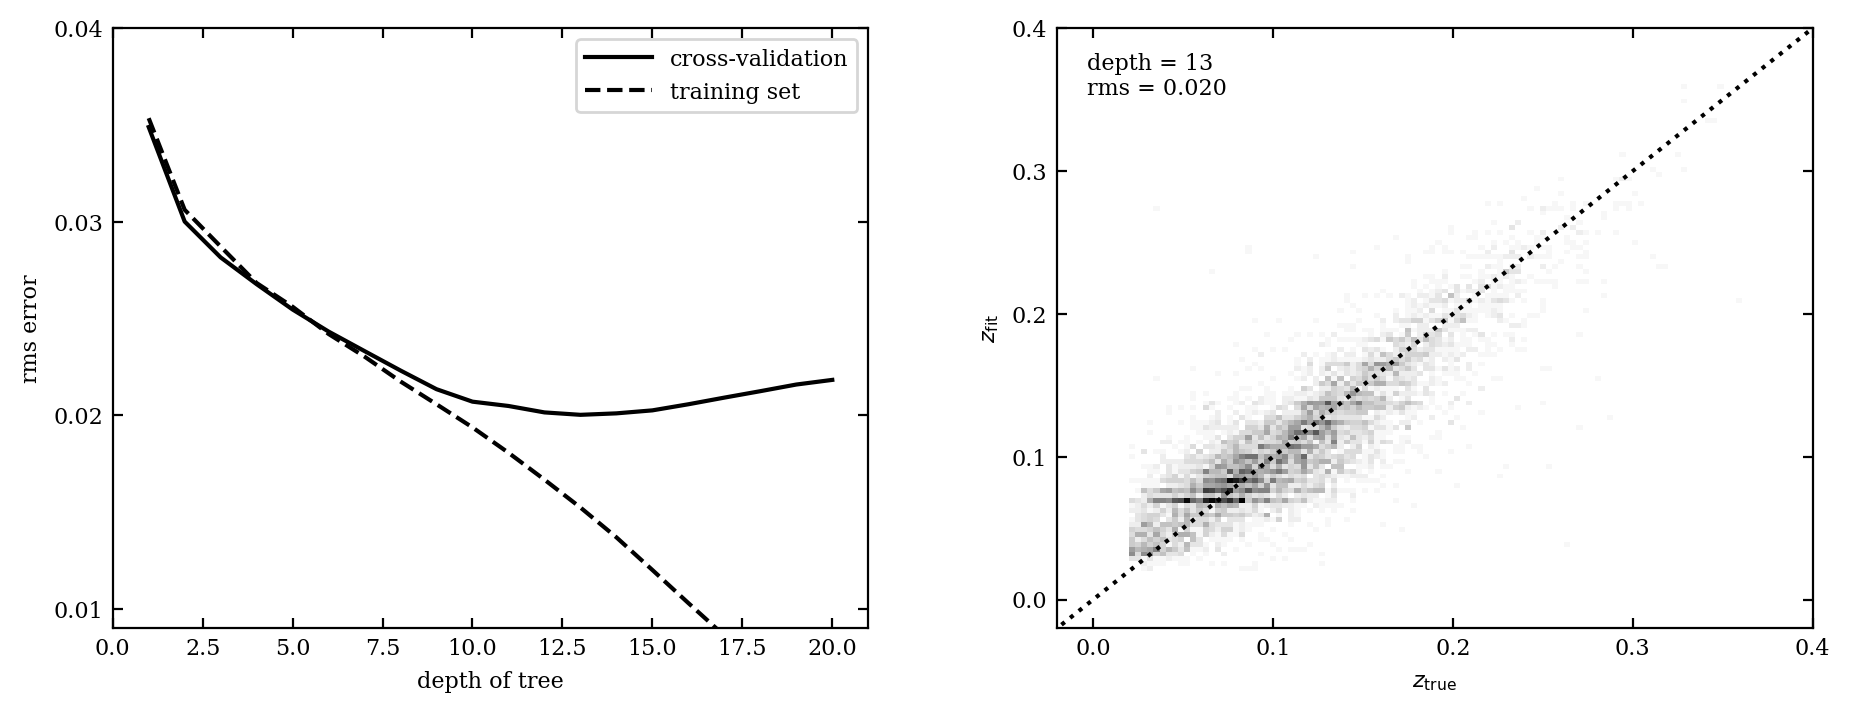

In [220]:
# Ivezic v2, Figure 9.14
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from sklearn.tree import DecisionTreeRegressor
from astroML.datasets import fetch_sdss_specgals

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Fetch data and prepare it for the computation
data = fetch_sdss_specgals()

# put magnitudes in a matrix
mag = np.vstack([data['modelMag_%s' % f] for f in 'ugriz']).T
z = data['z']

# train on ~60,000 points
mag_train = mag[::10]
z_train = z[::10]

# test on ~6,000 separate points
mag_test = mag[1::100]
z_test = z[1::100]

#------------------------------------------------------------
# Compute the cross-validation scores for several tree depths
depth = np.arange(1, 21)
rms_test = np.zeros(len(depth))
rms_train = np.zeros(len(depth))
i_best = 0
z_fit_best = None

for i, d in enumerate(depth):
    clf = DecisionTreeRegressor(max_depth=d, random_state=0)
    clf.fit(mag_train, z_train)

    z_fit_train = clf.predict(mag_train)
    z_fit = clf.predict(mag_test)
    rms_train[i] = np.mean(np.sqrt((z_fit_train - z_train) ** 2))
    rms_test[i] = np.mean(np.sqrt((z_fit - z_test) ** 2))

    if rms_test[i] <= rms_test[i_best]:
        i_best = i
        z_fit_best = z_fit

best_depth = depth[i_best]

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(wspace=0.25,
                    left=0.1, right=0.95,
                    bottom=0.15, top=0.9)

# first panel: cross-validation
ax = fig.add_subplot(121)
ax.plot(depth, rms_test, '-k', label='cross-validation')
ax.plot(depth, rms_train, '--k', label='training set')
ax.set_xlabel('depth of tree')
ax.set_ylabel('rms error')
ax.yaxis.set_major_locator(plt.MultipleLocator(0.01))
ax.set_xlim(0, 21)
ax.set_ylim(0.009,  0.04)
ax.legend(loc=1)

# second panel: best-fit results
ax = fig.add_subplot(122)
edges = np.linspace(z_test.min(), z_test.max(), 101)
H, zs_bins, zp_bins = np.histogram2d(z_test, z_fit_best, bins=edges)
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto', 
           extent=[zs_bins[0], zs_bins[-1], zs_bins[0], zs_bins[-1]],
           cmap=plt.cm.binary)
ax.plot([-0.1, 0.4], [-0.1, 0.4], ':k')
ax.text(0.04, 0.96, "depth = %i\nrms = %.3f" % (best_depth, rms_test[i_best]),
        ha='left', va='top', transform=ax.transAxes)
ax.set_xlabel(r'$z_{\rm true}$')
ax.set_ylabel(r'$z_{\rm fit}$')

ax.set_xlim(-0.02, 0.4001)
ax.set_ylim(-0.02, 0.4001)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))

plt.show()

We have just done cross validation by hand, lets use the Moons data set from Sklearn.

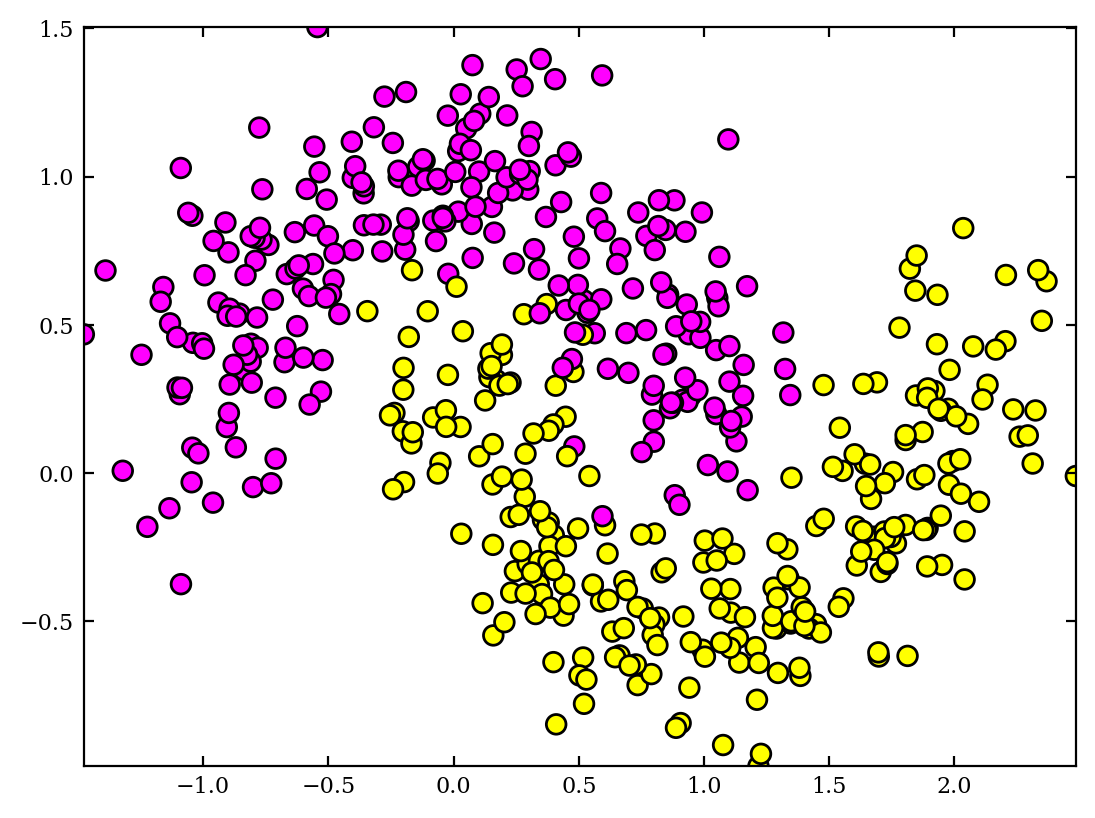

In [221]:

from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.20, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='spring',edgecolor='k');

Here we use gridsearch cross validation.

In [222]:
from sklearn.model_selection import GridSearchCV

clf = DecisionTreeClassifier()
drange = np.arange(1,21) 

grid = GridSearchCV(clf, param_grid={'max_depth': drange}, cv=5)
grid.fit(X, y)

best = grid.best_params_['max_depth']
print("best parameter choice:", best)

best parameter choice: 5


Plot the decision boundary:

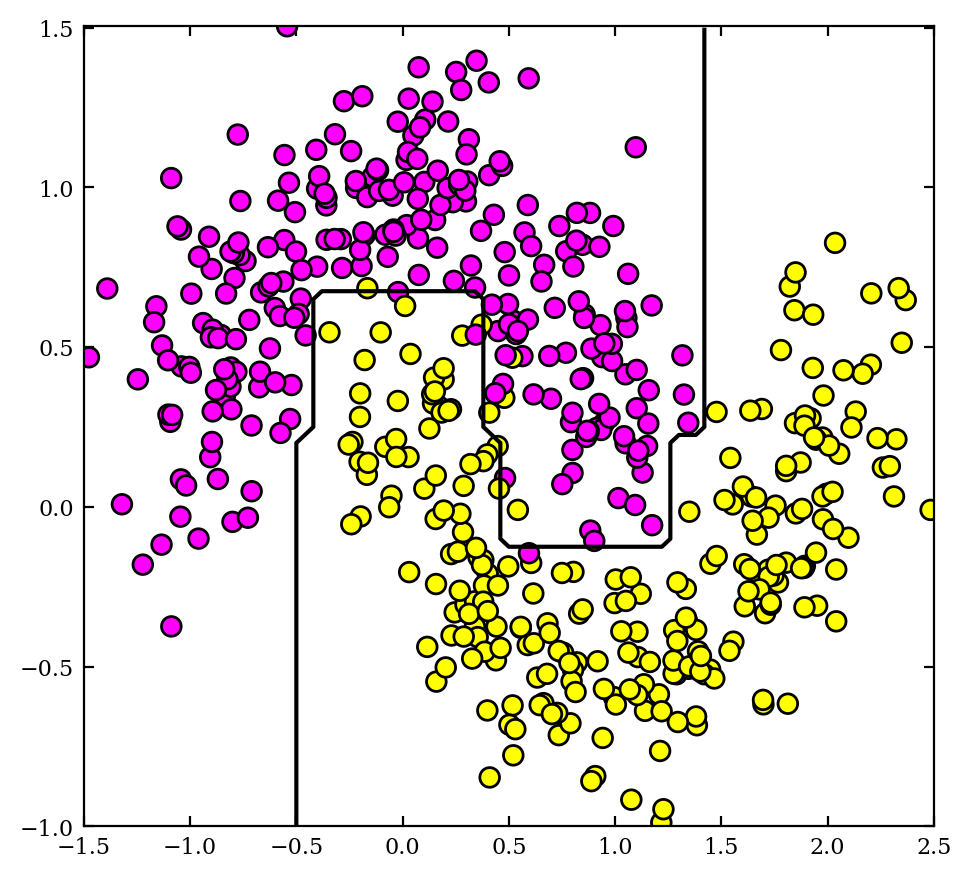

In [223]:
dt = DecisionTreeClassifier(random_state=0, max_depth=best, 
                            criterion='entropy')
dt.fit(X, y)
yprob = dt.predict_proba(X) # If we wanted probabilities rather than the discrete classes

xlim = (-1.5, 2.5)
ylim = (-1, 1.5)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 51),
                     np.linspace(ylim[0], ylim[1], 51))
xystack = np.vstack([xx.ravel(),yy.ravel()])
Xgrid = xystack.T

Z = dt.predict(Xgrid)
Z = Z.reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(5, 5))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(111)
im = ax.scatter(X[:, 0], X[:, 1], c=y, s=50, 
                cmap=plt.cm.spring, zorder=2, edgecolor='k')

ax.contour(xx, yy, Z, [0.5], colors='k');

### Ensemble Learning

This is the idea of combining the outputs of multiple models through voting or averaging and we will look at bagging and random forests. 

#### Bagging (Bootstrap Aggregation)

Bagging averages the predictive results of a series of bootstrap samples from the training set of data. This can improve the performance of decision trees by quite a bit. 

Remember that bootstrapping says to draw from the observed data set with replacement, so we select indices from the range $\{1,\ldots,N\}$ and this is our new sample. Indices can be repeated, and we do this B times.

So for a sample of $N$ points in a training set, bagging generates $B$ equally sized bootstrap samples from which to estimate the function $f_i(x)$. Hence, the final estimator for $\hat{y}$ is:

$$\hat{y} = f(x) = \frac{1}{B} \sum_i^B f_i(x).$$



Let us see how the moons data regular tree compares to when we use bagging, making the data a little noisier:

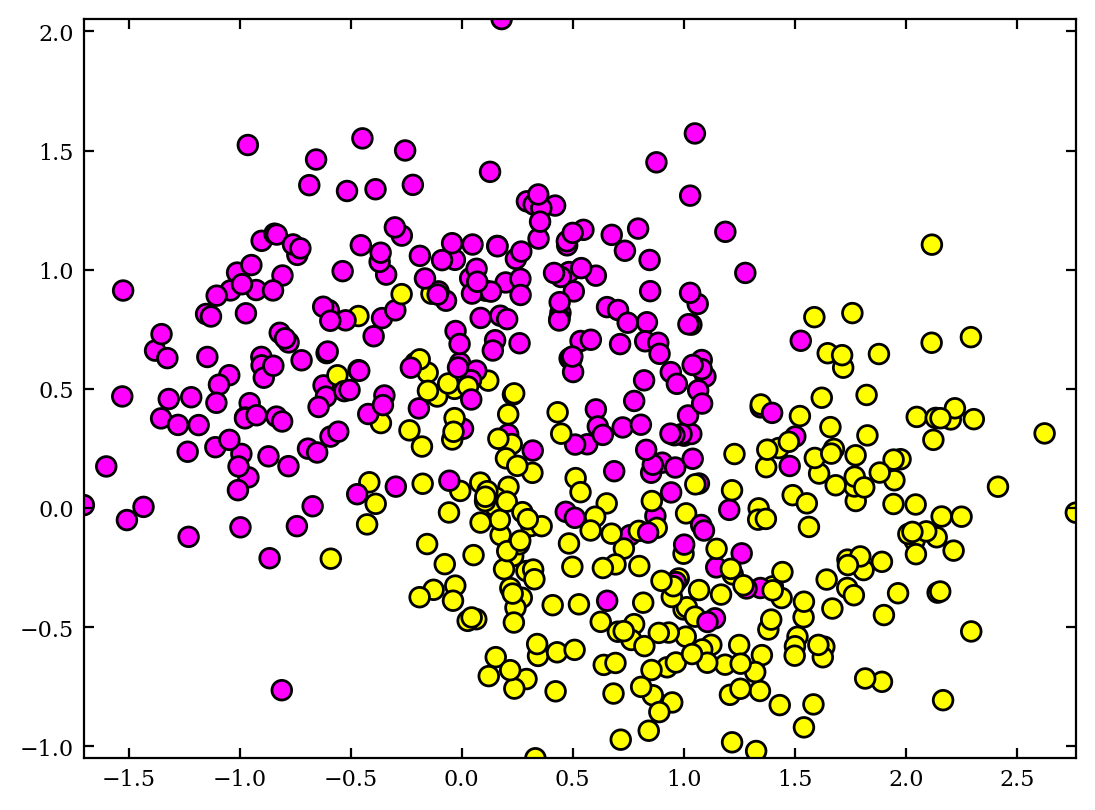

In [224]:

# Following example from Geron
X, y = make_moons(n_samples=500, noise=0.30, random_state= 12)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, 
            cmap='spring',edgecolor='k')

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [225]:
# Regular Decision Tree
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)

In [226]:
# Bagged Decision Tree
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42), 
    n_estimators=500, max_samples=100, 
    bootstrap=True, random_state=42, n_jobs=-1) # the n_jobs says to use all cores of the machine to do the job

%timeit bag_clf.fit(X_train, y_train)

y_pred_bag = bag_clf.predict(X_test)

62.5 ms ± 6.75 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [227]:
# Now compare the scores
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred_tree))
print(accuracy_score(y_test, y_pred_bag))

0.864
0.896


In [228]:
#From Geron for plotting the decision boundary
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.45, 
                                            -1, 1.5], 
                           alpha=0.5, contour=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], 
             "yo", alpha=alpha)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], 
             "bs", alpha=alpha)
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

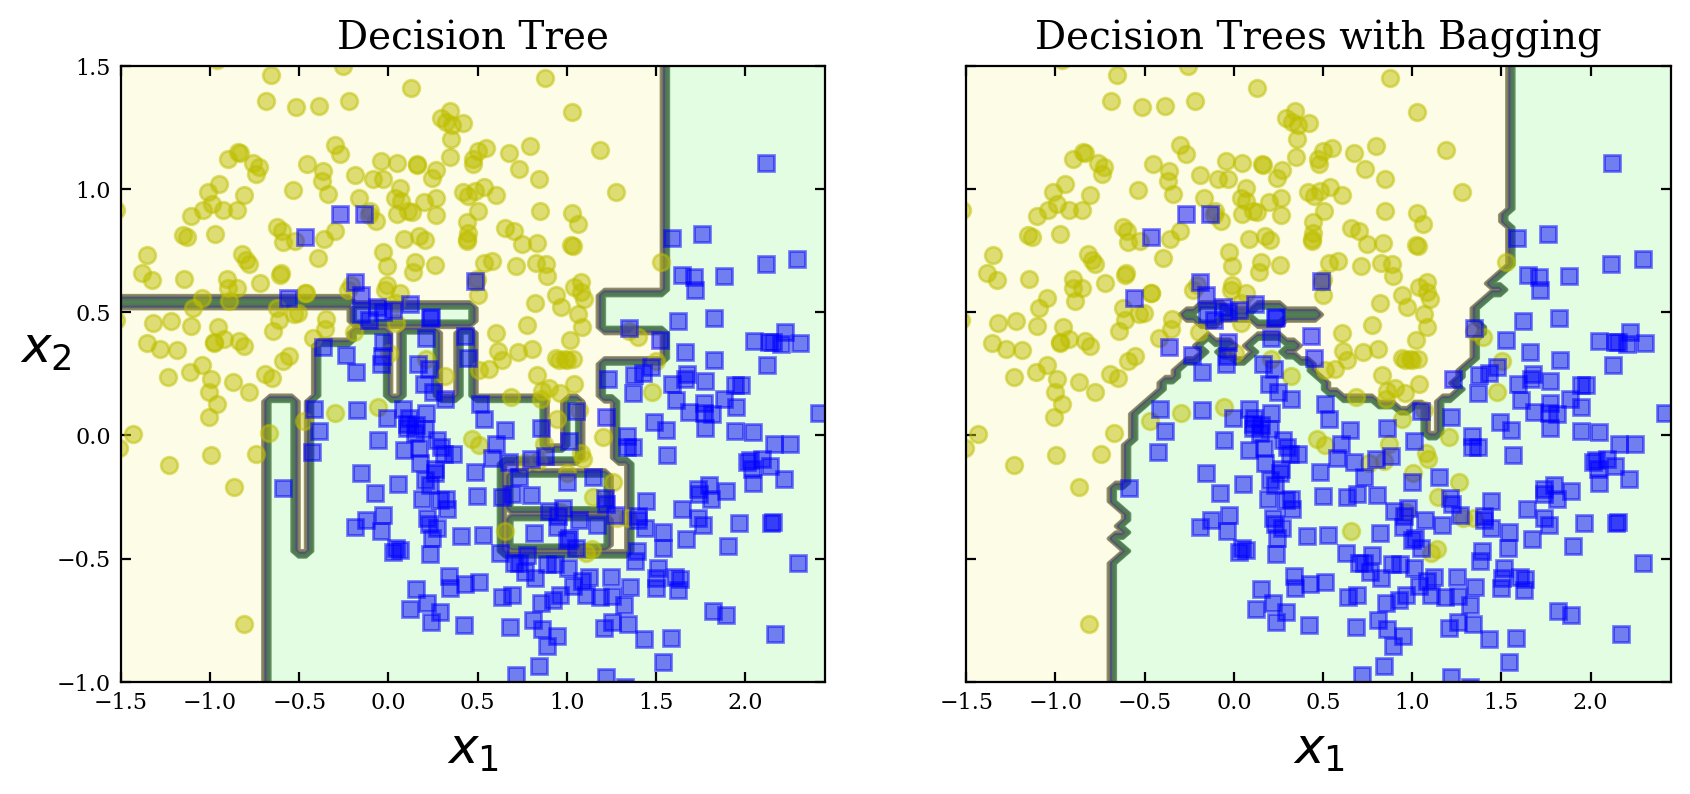

In [229]:
fix, axes = plt.subplots(ncols=2, figsize=(10,4), sharey=True)

plt.sca(axes[0])
plot_decision_boundary(tree_clf, X, y)
plt.title("Decision Tree", fontsize=14)

plt.sca(axes[1])
plot_decision_boundary(bag_clf, X, y)
plt.title("Decision Trees with Bagging", fontsize=14)

plt.ylabel("")
plt.show()

### Random Forests

This extends **bagging**. In addition to drawing random bootstrap samples from our training set, we also generate a set of decision trees from these samples. At each node, only a random subset of the available features is considered when choosing the best split.

The final classification from the Random Forest is based on combining the predictions from all of the individual trees.

This addresses two limitations of individual decision trees:

- Deep trees can have **high variance** and overfit the training data

- Individual trees produce axis-aligned, blocky decision boundaries, while combining many different trees can produce a more flexible overall boundary

When generating Random Forests:

- We define $n$, the number of trees that we will generate, and $m$, the number of features considered at each split

- For each decision tree, a bootstrap sample of the data is selected from the full training set

- At each node of the tree, a set of $m$ features are randomly selected and the splitting criterion is evaluated for these features. A different random set of $m$ features is selected at each node

- The final prediction is found by combining the predictions from all trees, usually using the **mode/majority vote for classification** and the **mean for regression**

A common choice for classification is to use approximately the square root of the total number of features at each split:

$$
m \approx \sqrt{D},
$$

where $D$ is the total number of available features.



To find the optimal depth, we use cross validation. The number of trees chosen is usually where the cross validation error plateaus.

Lets see an implementation for photometric estimation of galaxy redshifts.

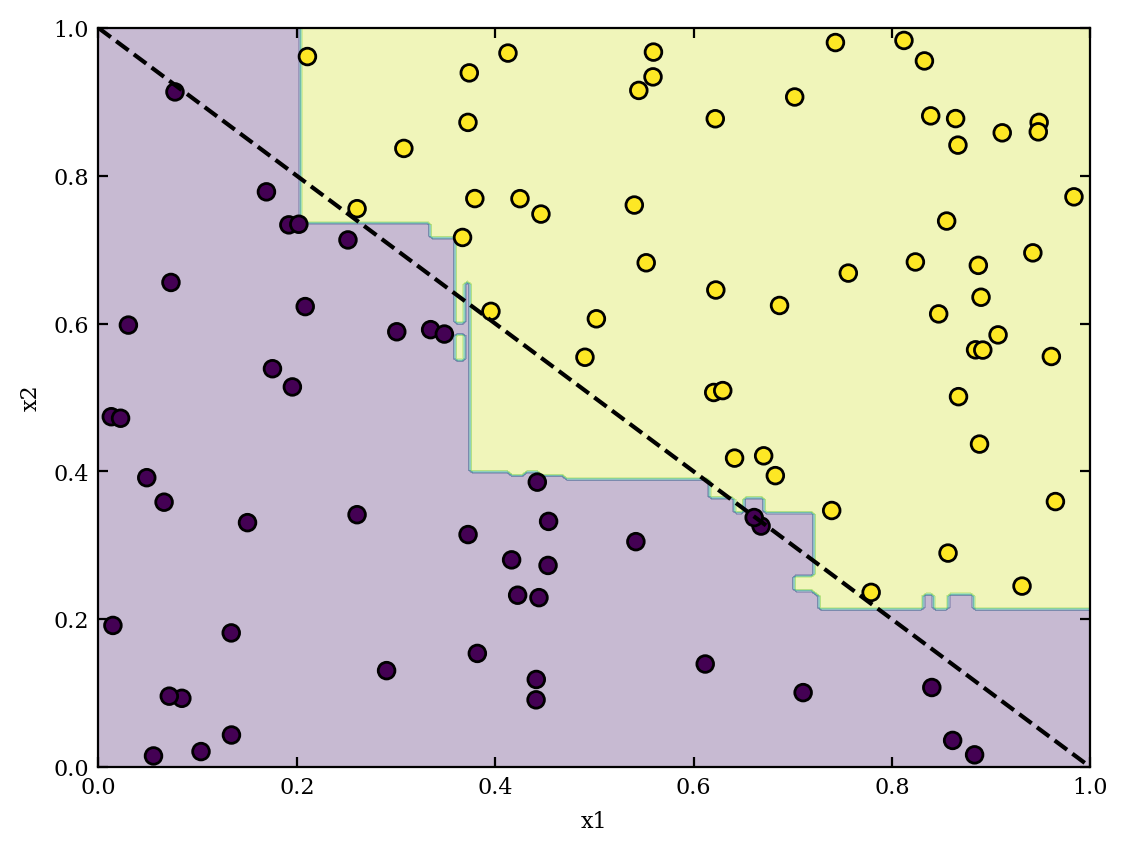

In [230]:
from sklearn.ensemble import RandomForestClassifier

X = np.random.random((100,2))
y = (X[:,0] + X[:,1] > 1).astype(int)

ranfor = RandomForestClassifier(10) # Creates a forest with 10 decision trees, each tree gets different bootstrap sample and randomness in features considered at splits
ranfor.fit(X,y)

# Grid
x1 = np.linspace(0, 1, 200)
x2 = np.linspace(0, 1, 200)
xx, yy = np.meshgrid(x1, x2)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = ranfor.predict(grid).reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')

# True boundary
plt.plot(x1, 1 - x1, 'k--')

plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

@pickle_results: using precomputed results from 'photoz_forest.pkl'


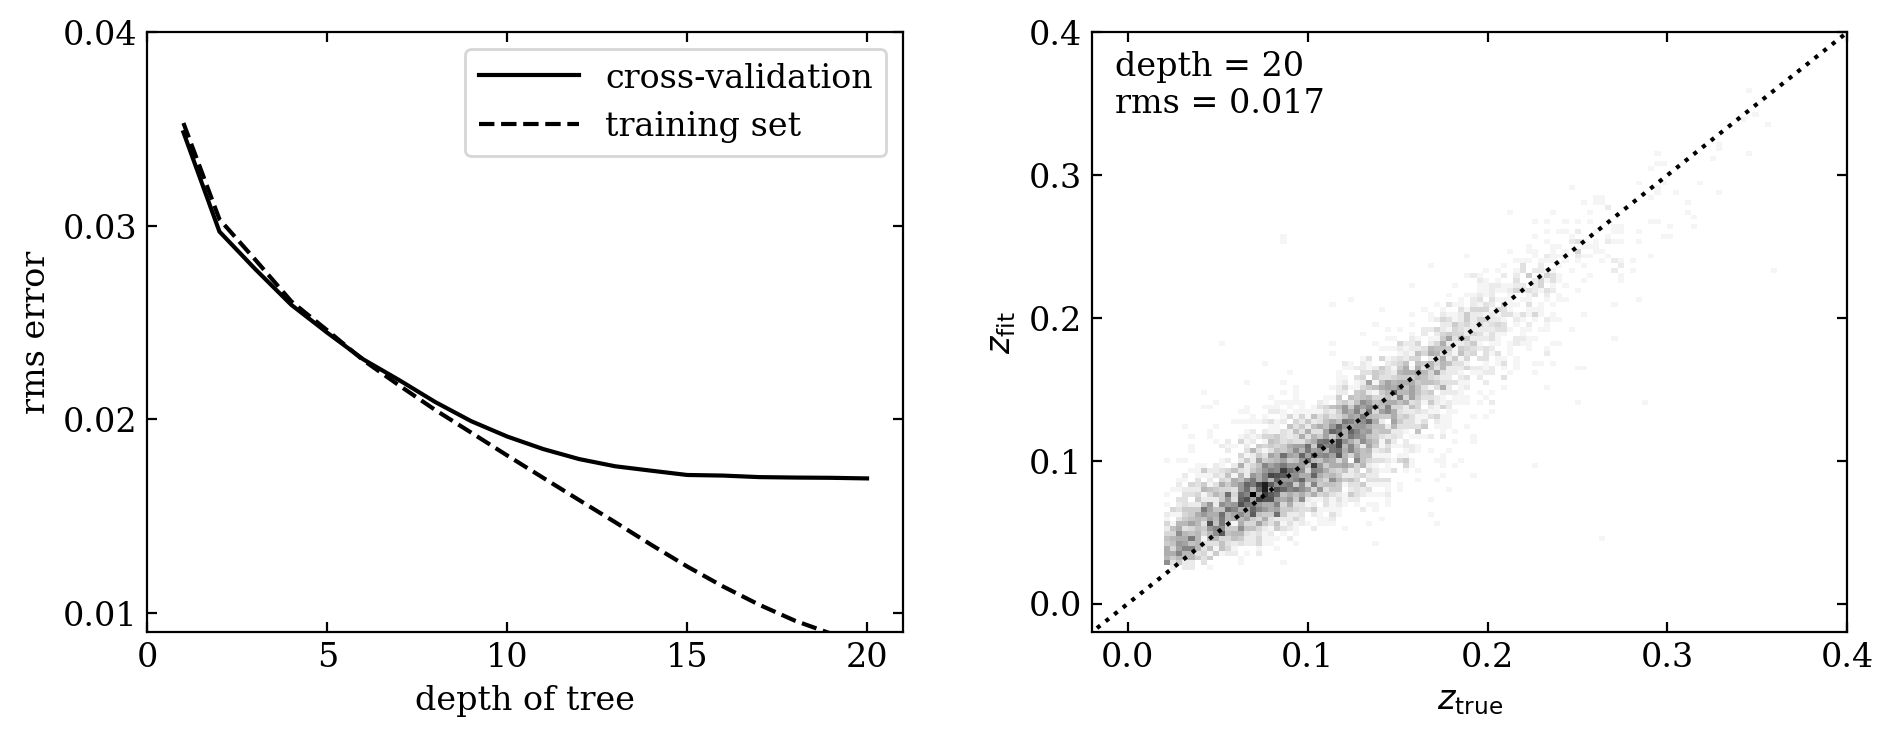

In [231]:
# Ivezic v2, Figure 9.15, edits by GTR and SRT
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from sklearn.ensemble import RandomForestRegressor
from astroML.datasets import fetch_sdss_specgals
from astroML.utils.decorators import pickle_results

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=12, usetex=False)

#------------------------------------------------------------
# Fetch and prepare the data
data = fetch_sdss_specgals()

# put magnitudes in a matrix
mag = np.vstack([data['modelMag_%s' % f] for f in 'ugriz']).T
z = data['z']

# train on ~60,000 points
mag_train = mag[::10]
z_train = z[::10]

# test on ~6,000 distinct points
mag_test = mag[1::100]
z_test = z[1::100]


#------------------------------------------------------------
# Compute the results
#  This is a long computation, so we'll save the results to a pickle.
@pickle_results('photoz_forest.pkl')
def compute_photoz_forest(depth):
    rms_test = np.zeros(len(depth))
    rms_train = np.zeros(len(depth))
    i_best = 0
    z_fit_best = None

    for i, d in enumerate(depth):
        clf = RandomForestRegressor(n_estimators=10,
                                    max_depth=d, random_state=0)
        clf.fit(mag_train, z_train)

        z_fit_train = clf.predict(mag_train)
        z_fit = clf.predict(mag_test)
        rms_train[i] = np.mean(np.sqrt((z_fit_train - z_train) ** 2))
        rms_test[i] = np.mean(np.sqrt((z_fit - z_test) ** 2))

        if rms_test[i] <= rms_test[i_best]:
            i_best = i
            z_fit_best = z_fit

    return rms_test, rms_train, i_best, z_fit_best


depth = np.arange(1, 21)
rms_test, rms_train, i_best, z_fit_best = compute_photoz_forest(depth)
best_depth = depth[i_best]

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(wspace=0.25,
                    left=0.1, right=0.95,
                    bottom=0.15, top=0.9)

# left panel: plot cross-validation results
ax = fig.add_subplot(121)
ax.plot(depth, rms_test, '-k', label='cross-validation')
ax.plot(depth, rms_train, '--k', label='training set')
ax.legend(loc=1)

ax.set_xlabel('depth of tree')
ax.set_ylabel('rms error')

ax.set_xlim(0, 21)
ax.set_ylim(0.009,  0.04)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.01))

# right panel: plot best fit
ax = fig.add_subplot(122)

edges = np.linspace(z_test.min(), z_test.max(), 101)
H, zs_bins, zp_bins = np.histogram2d(z_test, z_fit_best, bins=edges)
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto', 
           extent=[zs_bins[0], zs_bins[-1], zs_bins[0], zs_bins[-1]],
           cmap=plt.cm.binary)

ax.plot([-0.1, 0.4], [-0.1, 0.4], ':k')
ax.text(0.03, 0.97, "depth = %i\nrms = %.3f" % (best_depth, rms_test[i_best]),
        ha='left', va='top', transform=ax.transAxes)

ax.set_xlabel(r'$z_{\rm true}$')
ax.set_ylabel(r'$z_{\rm fit}$')

ax.set_xlim(-0.02, 0.4001)
ax.set_ylim(-0.02, 0.4001)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))

plt.show()

### Boosting

Boosting is where we use many weak classifiers, combine them to improve our classification. It creates models that attempt to correct the errors of the ensemble so far.

We rewrite the data based on how incorrectly the data was classified in the previous iteration. (This is useful in deep learning and will be called an "epoch")

- We run the classification multiple times and each time reweight the data based on the previous performance of the classifier
- At the end of this procedure, we allow the classifiers to vote on the final classification

Most popular form of boosting is **adaptive boosting**. In this case we take a weak classifier, $h(x)$ and create a strong classifier f(x) as:

$$f(x) = \sum_m^B\theta_m h_m(x),$$

Where $m$ is the number of iterations and $\theta_m$ is the weight of the classifier in each iteration. 

### I shall finish this later